# Heart Disease Prediction with Machine Learning

## 1. Problem Definition

In this project, we build a machine learning model to predict whether a patient has **heart disease** based on clinical attributes such as age, blood pressure, cholesterol level, chest pain type, ECG results, and exercise-related measurements.

This is formulated as a **binary classification problem**:

- **0** → No heart disease
- **1** → Presence of heart disease

The goal is to:
- Perform **exploratory data analysis (EDA)**,
- Apply and compare several **supervised learning algorithms**,
- Evaluate their performance using appropriate **classification metrics**,
- Apply **hyperparameter optimization**, **feature selection**, and **PCA** to improve performance.

We use the **UCI Heart Disease dataset (Cleveland subset)** as our data source.


## 2. Data Loading and Initial Preparation

In this section, we:

1. Import the required Python libraries.
2. Load the **processed.cleveland.data** file from the UCI Heart Disease dataset.
3. Assign meaningful column names based on the official UCI documentation.
4. Handle missing values encoded as "?".
5. Convert the **target** variable into a binary label:
   - 0 → no heart disease  
   - 1, 2, 3, 4 → heart disease (positive class).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.decomposition import PCA
from scipy.stats import ttest_rel
from scipy import stats

In [2]:
# 2.2 Define column names from UCI documentation
col_names = [
    "age",       # age in years
    "sex",       # sex (1 = male, 0 = female)
    "cp",        # chest pain type (0-3)
    "trestbps",  # resting blood pressure
    "chol",      # serum cholesterol
    "fbs",       # fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
    "restecg",   # resting ECG results
    "thalach",   # maximum heart rate achieved
    "exang",     # exercise induced angina (1 = yes, 0 = no)
    "oldpeak",   # ST depression induced by exercise relative to rest
    "slope",     # slope of peak exercise ST segment
    "ca",        # number of major vessels (0-3) colored by fluoroscopy
    "thal",      # thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)
    "target"     # originally 'num': 0 = no disease, 1-4 = disease
]

In [11]:
# 2.3 Load the dataset
data_path = "data/processed.cleveland.data"

df = pd.read_csv(
    data_path,
    names=col_names
)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [12]:
# 2.4 Replace "?" with NaN
df.replace("?", pd.NA, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [14]:
# 2.5 Convert 'ca' and 'thal' to numeric (they may contain NaN after replacing "?")
for col in ["ca", "thal"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [15]:
# 2.6 Convert target to binary: 0 = no disease, 1-4 = disease
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [8]:
# 2.7 Quick overview
print("First 5 rows:")
display(df.head())

print("\nInfo:")
print(df.info())

print("\nTarget value counts:")
print(df["target"].value_counts())

print("\nMissing values per column:")
print(df.isna().sum())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Target value counts:
target
0    164
1    139
Name: count, dtype: int64

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach 

### 2.3 Missing Values

In the original UCI processed Cleveland dataset, some values are encoded as `"?"`, 
especially in the **ca** (number of vessels) and **thal** (thalassemia) columns.
We replaced `"?"` with `NaN` and converted these columns to numeric.

Next, we handle the missing values by imputing them with the **median** of each column.
We choose the median because it is robust to outliers and keeps the distribution more stable than the mean.


In [16]:
# 2.8 Handle missing values by imputing median for numeric columns
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca", "thal", "fbs", "restecg", "exang", "slope"]

df[numeric_cols] = df[numeric_cols].astype("float64")

df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values after imputation:")
print(df.isna().sum())


Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

In this section, we follow a comprehensive EDA workflow based on the methods taught in Weeks 2–4 of the course:
- Pandas descriptive analysis  
- Summary statistics  
- Visual exploration using Matplotlib and Seaborn  
- Distribution and categorical analysis  
- Correlation structure  
- Hypothesis testing  

The goal is to understand the underlying structure of the Heart Disease dataset, identify important patterns, check for anomalies and outliers, and gain insights that will guide model selection and preprocessing.


In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


### 3.2 Summary Statistics

We first examine the numerical summary statistics, including mean, standard deviation, and quartiles.  
This provides an overview of patient characteristics and helps detect unusual values.


In [31]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 3.3 Categorical Feature Overview

The dataset includes several categorical medical indicators:
- **sex** (0 = female, 1 = male)
- **cp** chest pain type (0–3)
- **fbs** fasting blood sugar
- **restecg** ECG results
- **exang** exercise induced angina
- **slope** ST slope
- **thal** thalassemia  
- **target** (0 = no disease, 1 = disease)

We display their frequency distributions.


In [32]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal", "target"]
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())



Value counts for sex:
sex
1.0    206
0.0     97
Name: count, dtype: int64

Value counts for cp:
cp
4.0    144
3.0     86
2.0     50
1.0     23
Name: count, dtype: int64

Value counts for fbs:
fbs
0.0    258
1.0     45
Name: count, dtype: int64

Value counts for restecg:
restecg
0.0    151
2.0    148
1.0      4
Name: count, dtype: int64

Value counts for exang:
exang
0.0    204
1.0     99
Name: count, dtype: int64

Value counts for slope:
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

Value counts for thal:
thal
3.0    168
7.0    117
6.0     18
Name: count, dtype: int64

Value counts for target:
target
0    164
1    139
Name: count, dtype: int64


### 3.4 Distribution of Numerical Features

We visualize the distributions of key numerical variables such as age, cholesterol, resting blood pressure, and ST depression (`oldpeak`) using histograms and KDE plots.


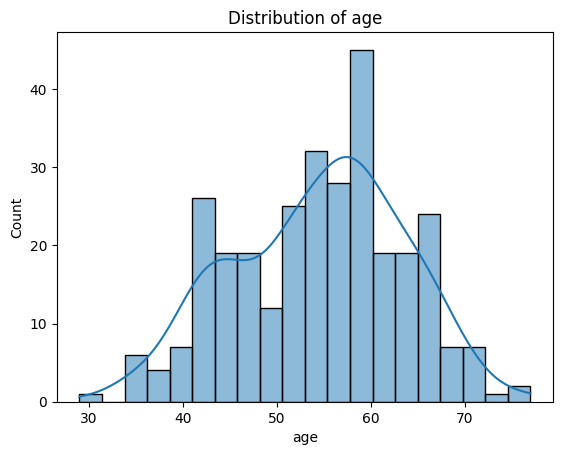

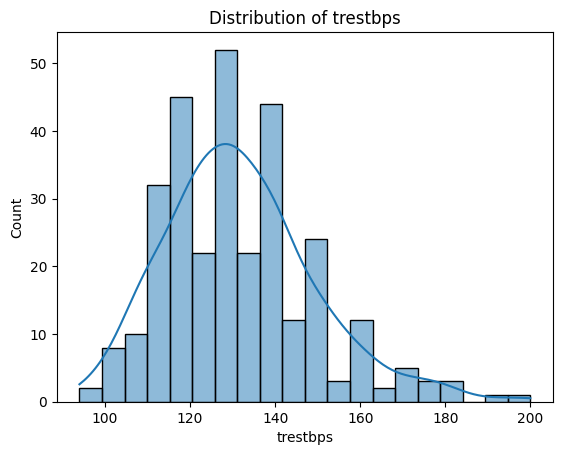

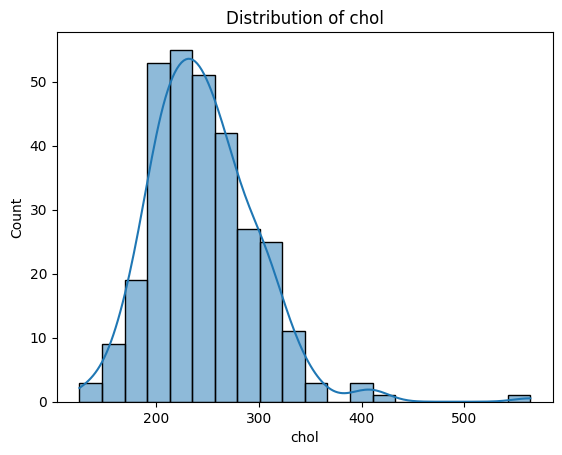

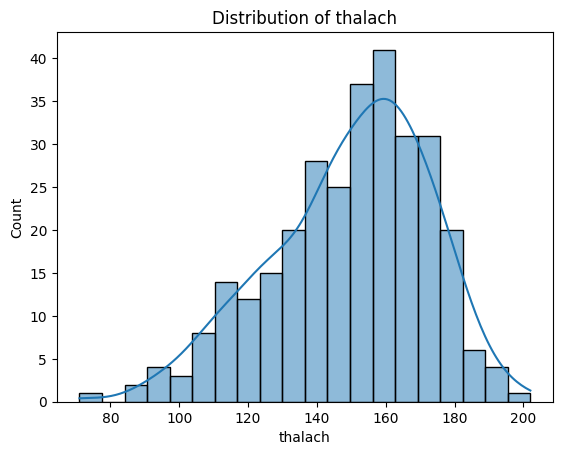

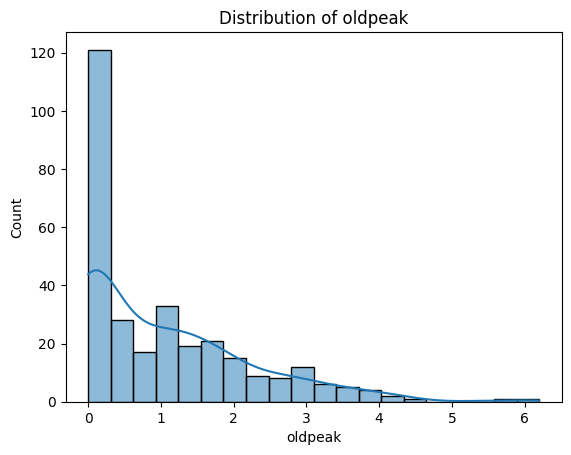

In [33]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for col in numeric_cols:
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()


### 3.5 Numerical Feature Distributions Grouped by Target

To explore how clinical features differ between patients with and without heart disease, we visualize distributions grouped by the target class.


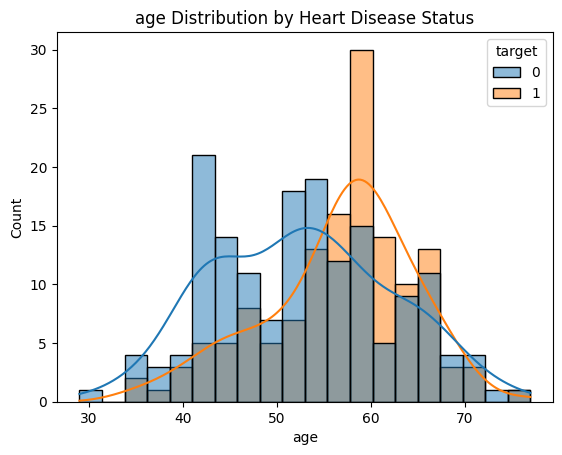

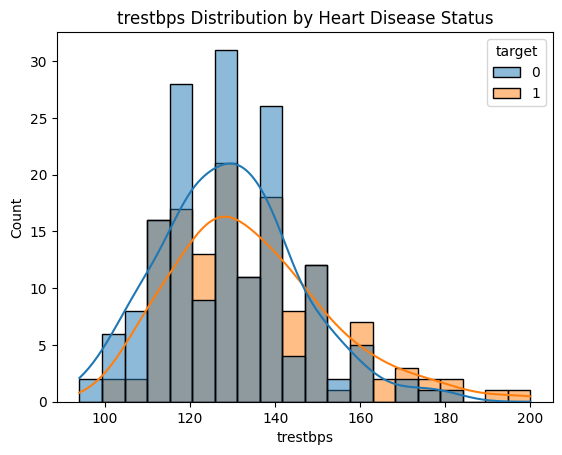

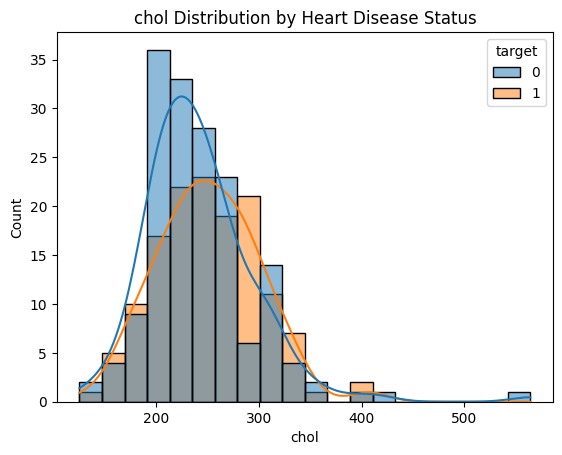

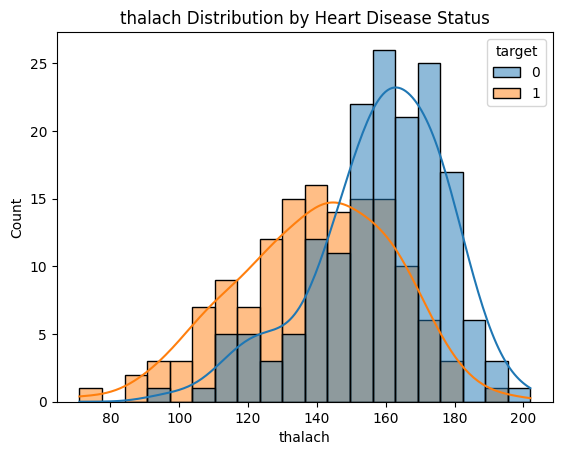

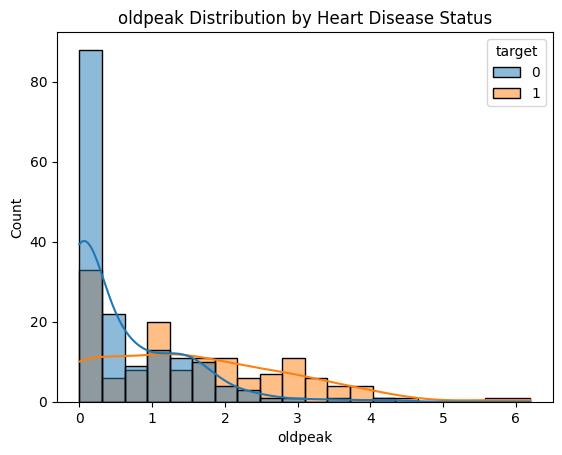

In [34]:
for col in numeric_cols:
    sns.histplot(data=df, x=col, hue="target", kde=True, bins=20)
    plt.title(f"{col} Distribution by Heart Disease Status")
    plt.show()


### 3.6 Boxplots for Outlier Visualization

Boxplots help visually identify extreme values that may represent medical abnormalities or measurement errors.


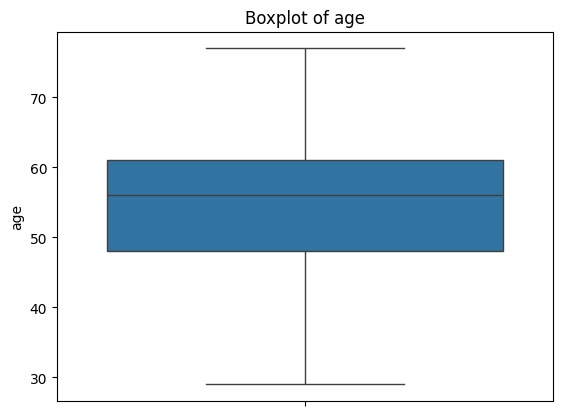

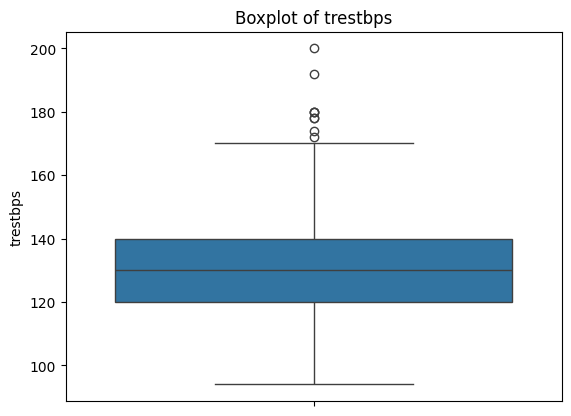

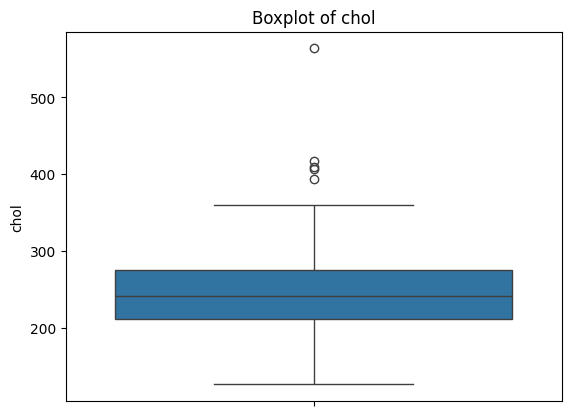

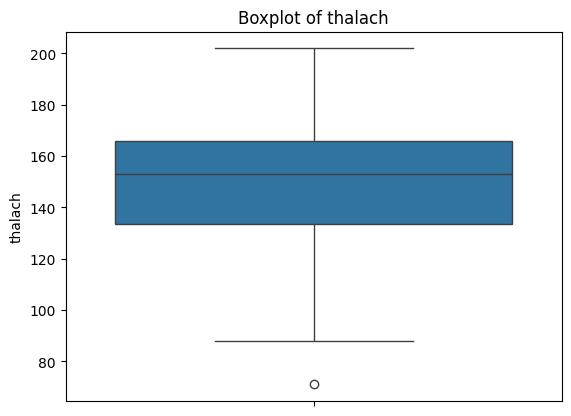

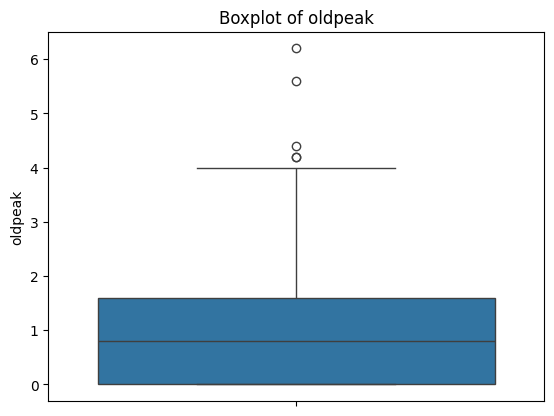

In [35]:
for col in numeric_cols:
    sns.boxplot(data=df, y=col)
    plt.title(f"Boxplot of {col}")
    plt.show()


### 3.7 Relationship Between Categorical Features and Heart Disease
We visualize how categorical medical indicators differ across disease vs non-disease patients.


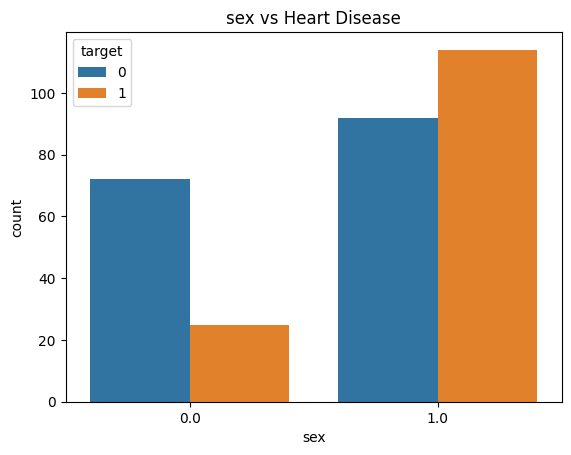

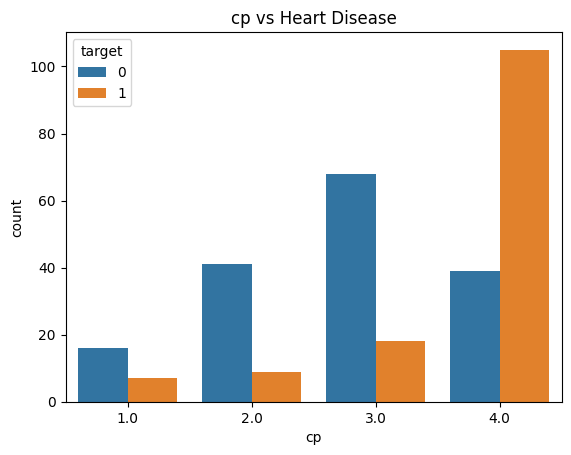

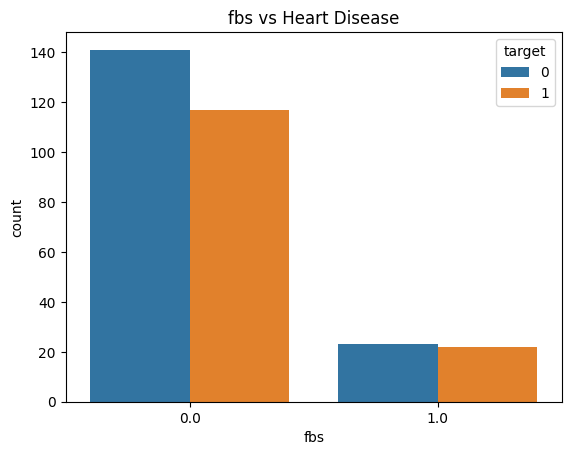

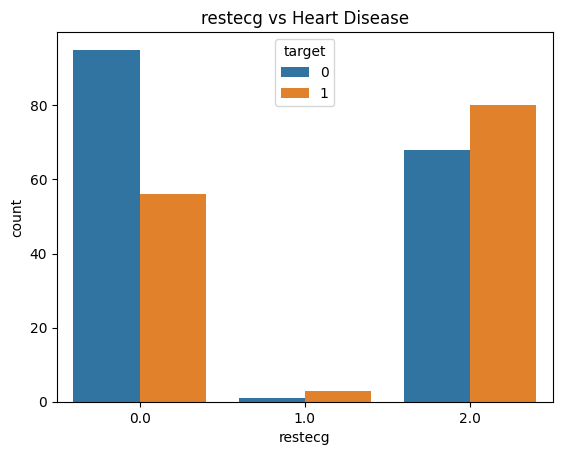

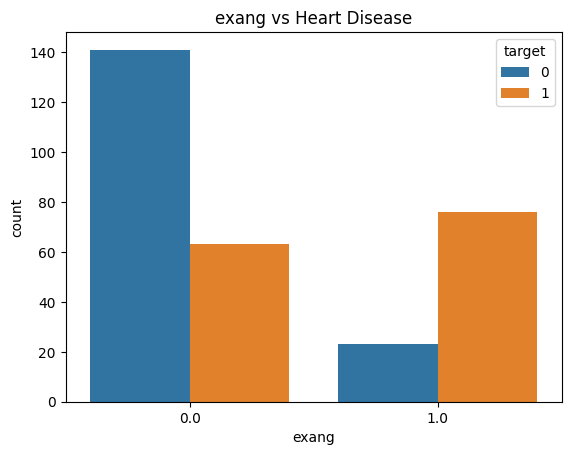

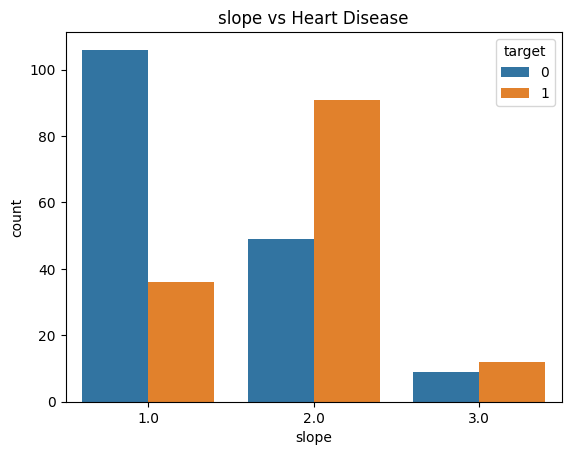

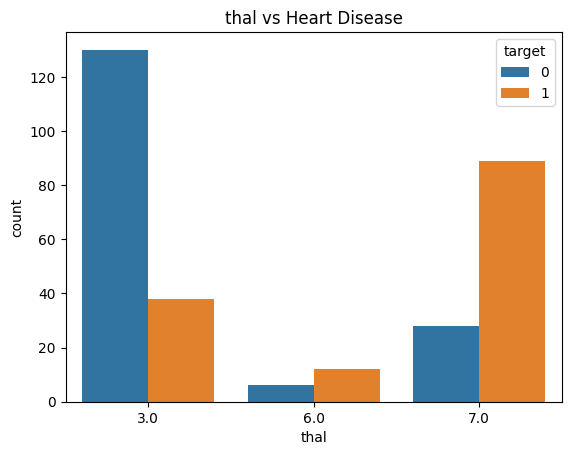

In [36]:
categorical_cols.remove("target")

for col in categorical_cols:
    sns.countplot(data=df, x=col, hue="target")
    plt.title(f"{col} vs Heart Disease")
    plt.show()


### 3.8 Correlation Heatmap

We compute the correlations between numerical variables to identify patterns such as:
- features strongly associated with heart disease  
- relationships between physiological measurements  


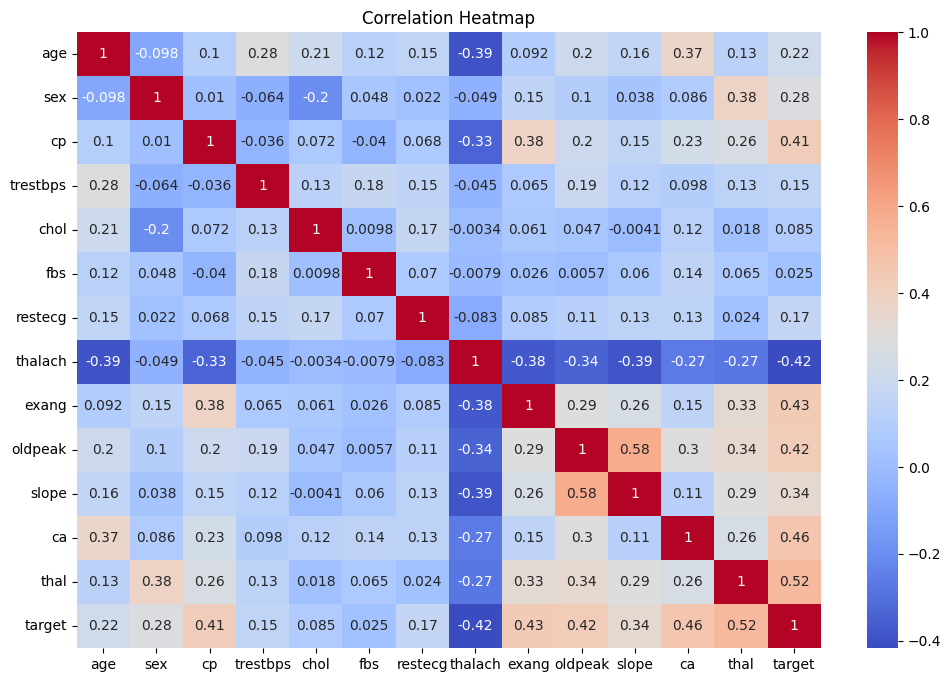

In [37]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### 3.9 Pairplot of Key Features

A pairplot visualizes pairwise relationships between features and highlights class separation patterns.
Due to computational cost, we include a subset of highly relevant features.


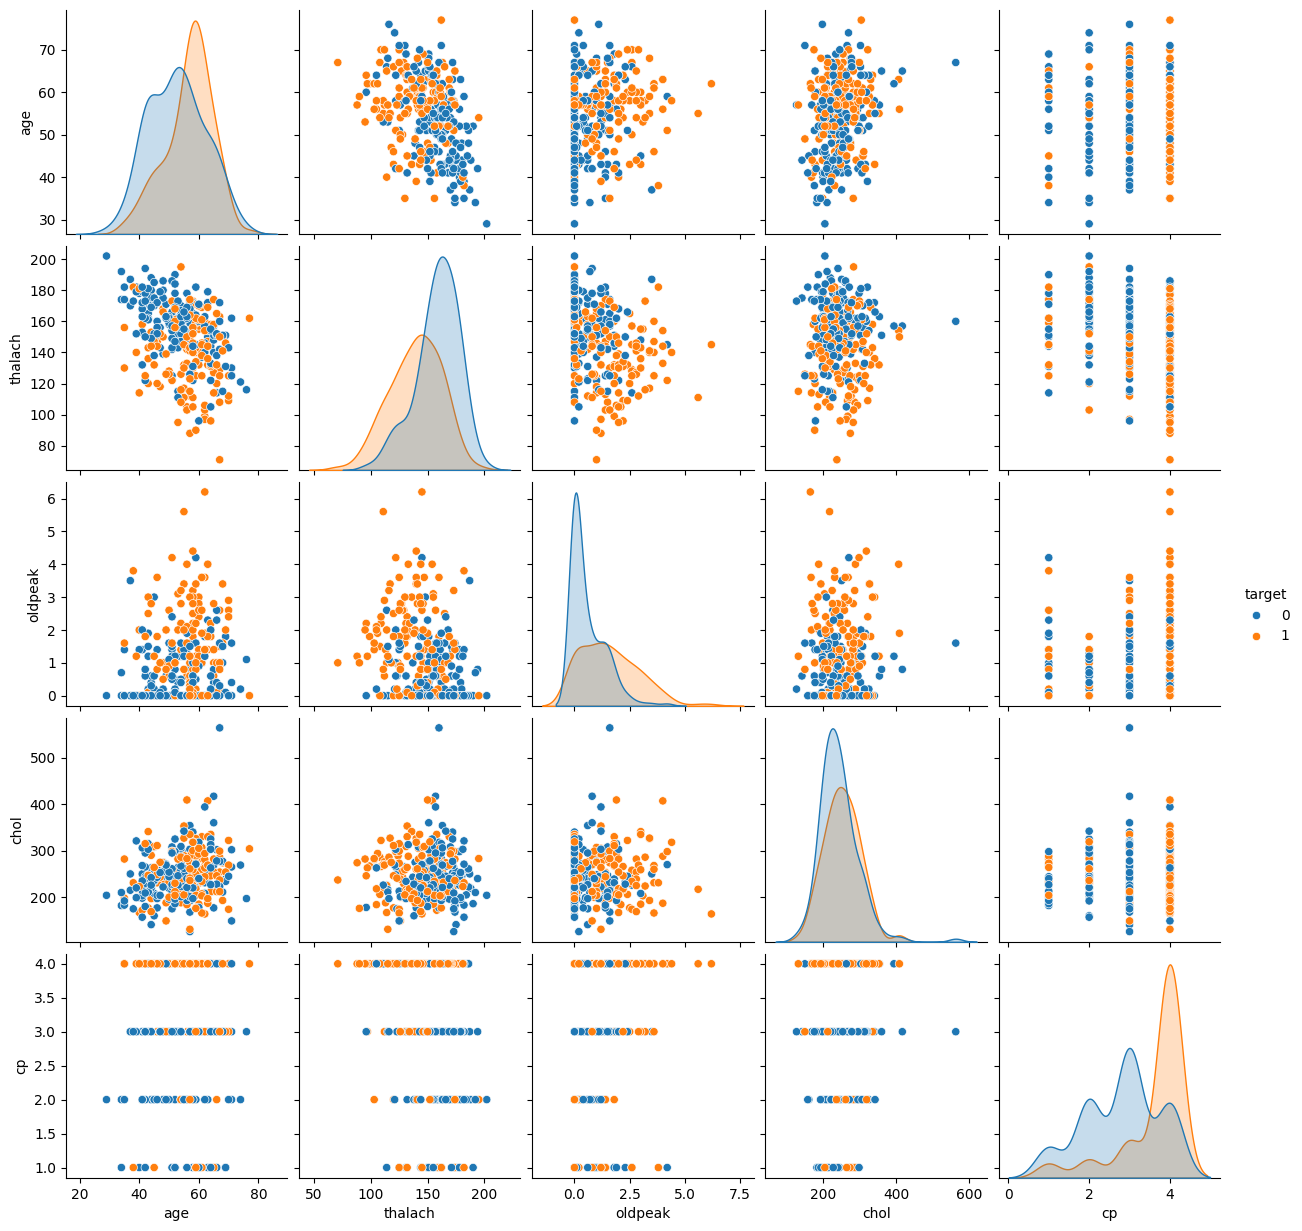

In [42]:
sns.pairplot(df[["age", "thalach", "oldpeak", "chol", "cp", "target"]], hue="target")
plt.show()


### 3.10 Hypothesis Testing: Cholesterol Levels

We test whether cholesterol levels (`chol`) differ significantly between patients  
with and without heart disease.

- **H0 (null hypothesis):** Mean cholesterol is the same for both groups  
- **H1 (alternative):** Mean cholesterol is different  


In [39]:
from scipy.stats import ttest_ind

chol_no = df[df["target"] == 0]["chol"]
chol_yes = df[df["target"] == 1]["chol"]

stat, p = ttest_ind(chol_no, chol_yes)

print("T-statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Result: Reject H0 → Cholesterol differs significantly between groups.")
else:
    print("Result: Fail to reject H0 → No significant difference.")


T-statistic: -1.4829209163941466
p-value: 0.13914167020436527
Result: Fail to reject H0 → No significant difference.


## 4. Outlier Detection and Treatment

Outliers are extreme data points that deviate significantly from the rest of the observations.  
In medical datasets, outliers may represent unusual physiological measurements, data entry errors, or truly abnormal patients.

According to the project requirements, we use **two different methods** to detect outliers:

1. **Interquartile Range (IQR) Method**  
2. **Z-Score Method**

After identifying outliers, we apply **Winsorization (capping)** instead of row removal, because removing medical records can reduce the dataset size and harm model performance.


In [43]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("IQR Outliers per Feature:\n")
for col in numeric_cols:
    out, low, high = iqr_outliers(df[col])
    print(f"{col}: {len(out)} outliers (lower={low:.2f}, upper={high:.2f})")


IQR Outliers per Feature:

age: 0 outliers (lower=28.50, upper=80.50)
trestbps: 9 outliers (lower=90.00, upper=170.00)
chol: 5 outliers (lower=115.00, upper=371.00)
thalach: 1 outliers (lower=84.75, upper=214.75)
oldpeak: 5 outliers (lower=-2.40, upper=4.00)


In [44]:
from scipy.stats import zscore

z_scores = df[numeric_cols].apply(zscore)

print("\nZ-Score Outliers per Feature (|z| > 3):\n")
for col in numeric_cols:
    outliers = df[(z_scores[col].abs() > 3)]
    print(f"{col}: {len(outliers)} outliers")



Z-Score Outliers per Feature (|z| > 3):

age: 0 outliers
trestbps: 2 outliers
chol: 4 outliers
thalach: 1 outliers
oldpeak: 2 outliers


### 4.3 Summary of Outlier Detection

Both methods identified outliers in key physiological features such as:
- **chol** (serum cholesterol)
- **trestbps** (resting blood pressure)
- **oldpeak** (ST depression)
- **thalach** (maximum heart rate)

These features naturally vary between individuals, but extreme values may negatively impact model training.

To avoid losing valuable medical records, we apply **capping (Winsorization)** rather than deleting rows.


In [45]:
def cap_outliers(series):
    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    return series.clip(lower, upper)

df_capped = df.copy()

for col in numeric_cols:
    df_capped[col] = cap_outliers(df_capped[col])

print("Outlier capping complete. New ranges:")
df_capped[numeric_cols].describe().T


Outlier capping complete. New ranges:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.419142,8.875476,35.00,48.0,56.0,61.0,71.00
trestbps,303.0,131.623762,17.174129,100.00,120.0,130.0,140.0,180.00
chol,303.0,246.293597,48.820772,149.00,211.0,241.0,275.0,406.74
thalach,303.0,149.676304,22.437258,95.02,133.5,153.0,166.0,191.96
oldpeak,303.0,1.027723,1.119258,0.00,0.0,0.8,1.6,4.20


### 4.4 Outlier Treatment

We used percentile-based Winsorization:

- Values below the **1st percentile** were replaced with the 1st percentile value  
- Values above the **99th percentile** were replaced with the 99th percentile value  

This approach:
- Reduces the influence of extreme values  
- Preserves all patient records  
- Stabilizes numerical features for machine learning  


In [46]:
df_capped


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
300,57.0,1.0,4.0,130.0,149.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


## 5. Data Preprocessing

To prepare the dataset for machine learning models, we apply several preprocessing steps:

1. **Feature–target separation**  
2. **Encoding of categorical variables** (One-Hot Encoding)  
3. **Scaling of numerical variables** (StandardScaler)  
4. **Train–test split**  
5. **Pipeline preparation**  

These steps ensure that the data is suitable for algorithms such as Logistic Regression, SVM, Random Forest, and Gradient Boosting.


In [47]:
df_ready = df_capped.copy()

X = df_ready.drop("target", axis=1)
y = df_ready["target"]

X.head(), y.head()


(    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
 0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
 1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
 2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
 3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
 4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
 
    slope   ca  thal  
 0    3.0  0.0   6.0  
 1    2.0  3.0   3.0  
 2    2.0  2.0   7.0  
 3    3.0  0.0   3.0  
 4    1.0  0.0   3.0  ,
 0    0
 1    1
 2    1
 3    0
 4    0
 Name: target, dtype: int64)

In [48]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [49]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (242, 13)
Test size: (61, 13)


### 5.1 Encoding and Scaling

We apply:

- **One-Hot Encoding** to categorical features  
  (sex, chest pain type, fasting blood sugar, ECG, angina, slope, ca, thal)

- **StandardScaler** to numerical features  
  (age, resting blood pressure, cholesterol, max heart rate, ST depression)

Standardizing numerical variables ensures that features with larger scales  
(e.g., cholesterol measured in mg/dl) do not dominate the training of models like:
- Logistic Regression  
- Support Vector Machines  
- KNN  

Encoding categorical values ensures that models can interpret non-numeric information.


In [51]:
from sklearn.pipeline import Pipeline

# Example pipeline (we will reuse this for all models)
logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logreg_pipeline


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 6. Machine Learning Models

We train and evaluate four supervised learning algorithms commonly used for classification:

1. **Logistic Regression** (baseline linear model)  
2. **Support Vector Machine (SVM)**  
3. **Random Forest Classifier** (ensemble of decision trees)  
4. **Gradient Boosting Classifier** (boosting-based ensemble)

Each model uses the same preprocessing pipeline (scaling + encoding) to ensure a fair comparison.
We evaluate the models using accuracy, precision, recall, F1-score, AUC, confusion matrix, and ROC curves.


In [55]:
#Utility Function to Evaluate Models
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    print(f"\n=== {model_name} ===")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("AUC      :", auc)

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
        plt.plot([0,1],[0,1], '--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{model_name} - ROC Curve")
        plt.legend()
        plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }



=== Logistic Regression ===
Accuracy : 0.8852459016393442
Precision: 0.8620689655172413
Recall   : 0.8928571428571429
F1 Score : 0.8771929824561403
AUC      : 0.961038961038961


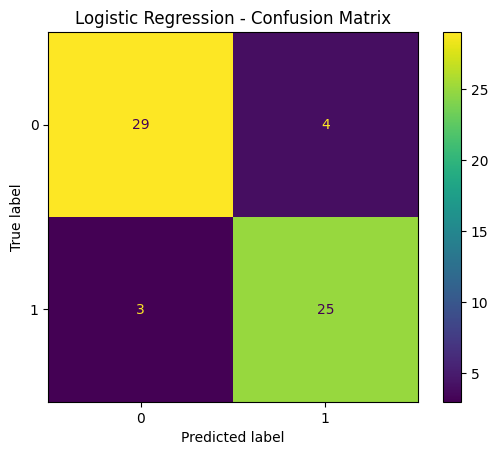

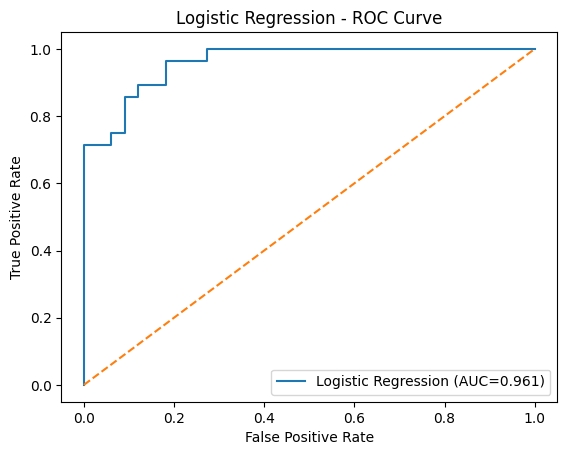

In [ ]:
# Train  Logistic Regression
logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logreg_pipeline.fit(X_train, y_train)

logreg_results = evaluate_model(logreg_pipeline, X_test, y_test, "Logistic Regression")



=== Support Vector Machine ===
Accuracy : 0.9180327868852459
Precision: 0.8709677419354839
Recall   : 0.9642857142857143
F1 Score : 0.9152542372881356
AUC      : 0.9664502164502164


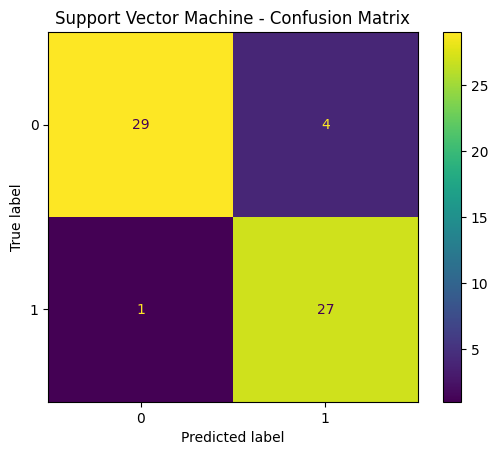

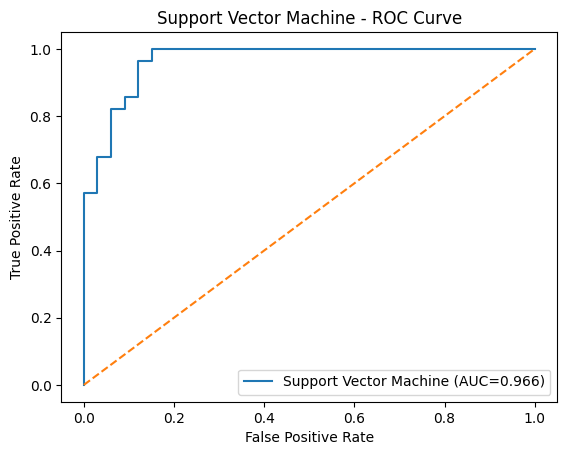

In [58]:
# Train Support Vector Machine (SVC)
svc_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", SVC(kernel="rbf", probability=True))
    ]
)

svc_pipeline.fit(X_train, y_train)

svc_results = evaluate_model(svc_pipeline, X_test, y_test, "Support Vector Machine")



=== Random Forest ===
Accuracy : 0.9016393442622951
Precision: 0.84375
Recall   : 0.9642857142857143
F1 Score : 0.9
AUC      : 0.9415584415584416


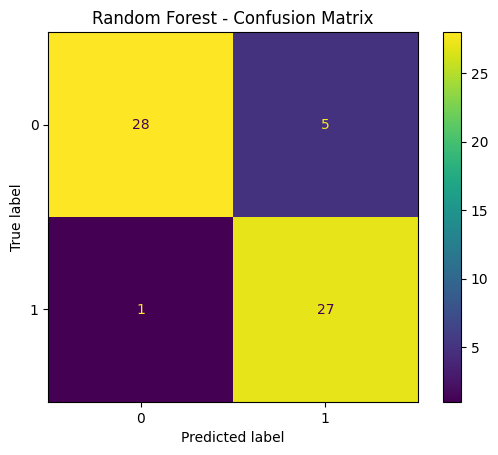

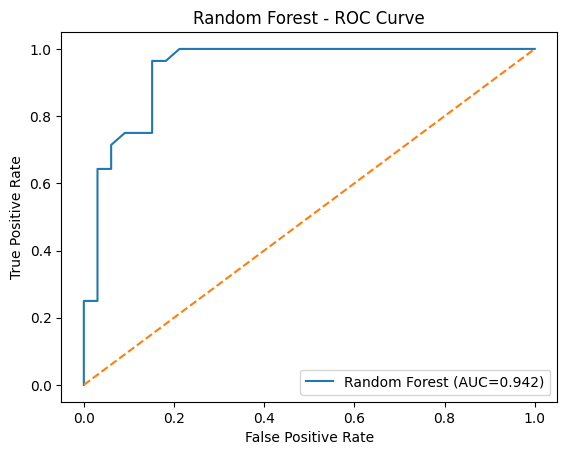

In [59]:
# Train Random Forest Classifier
rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_results = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")



=== Gradient Boosting ===
Accuracy : 0.8852459016393442
Precision: 0.8620689655172413
Recall   : 0.8928571428571429
F1 Score : 0.8771929824561403
AUC      : 0.9307359307359309


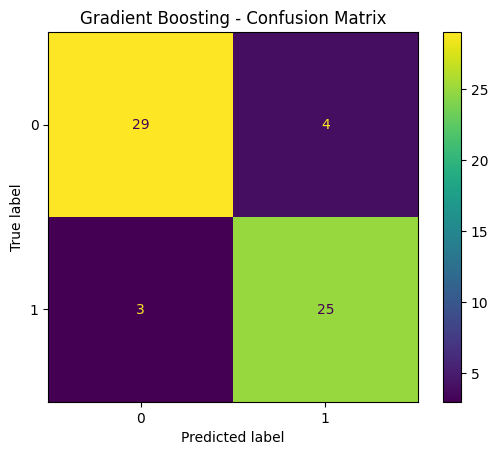

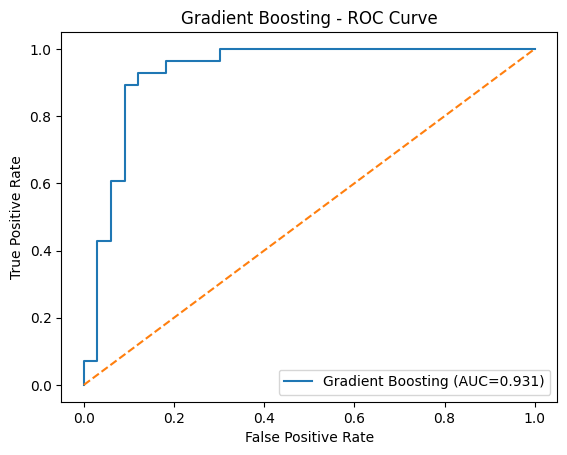

In [60]:
# Train Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier())
    ]
)

gb_pipeline.fit(X_train, y_train)

gb_results = evaluate_model(gb_pipeline, X_test, y_test, "Gradient Boosting")


In [61]:
# Create a Comparison Table
import pandas as pd

results_df = pd.DataFrame([
    logreg_results,
    svc_results,
    rf_results,
    gb_results
])

results_df


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.885246,0.862069,0.892857,0.877193,0.961039
1,Support Vector Machine,0.918033,0.870968,0.964286,0.915254,0.966450
2,Random Forest,0.901639,0.843750,0.964286,0.900000,0.941558
3,Gradient Boosting,0.885246,0.862069,0.892857,0.877193,0.930736


## 7. Hyperparameter Optimization

For each model, we apply **GridSearchCV** with 5-fold cross validation to search for the best hyperparameters.
We use **F1-score** as the optimization metric because it balances precision and recall and is appropriate for slightly imbalanced classes.

The tuned models are then evaluated again on the test set, and the results are compared to the baseline models.


In [66]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)


In [72]:
# hide the warnings for cleaner output
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)


Best Logistic Regression params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV F1: 0.8212094436983104

=== LogReg (Tuned) ===
Accuracy : 0.8852459016393442
Precision: 0.8620689655172413
Recall   : 0.8928571428571429
F1 Score : 0.8771929824561403
AUC      : 0.961038961038961


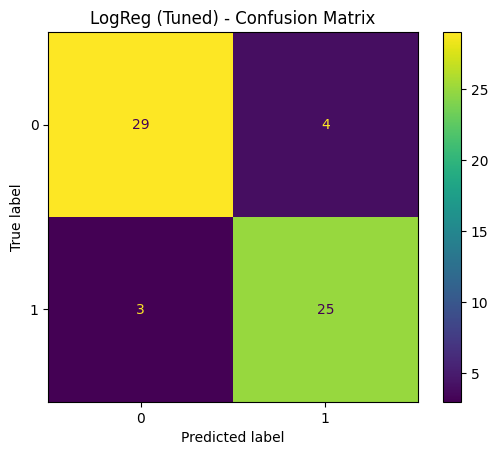

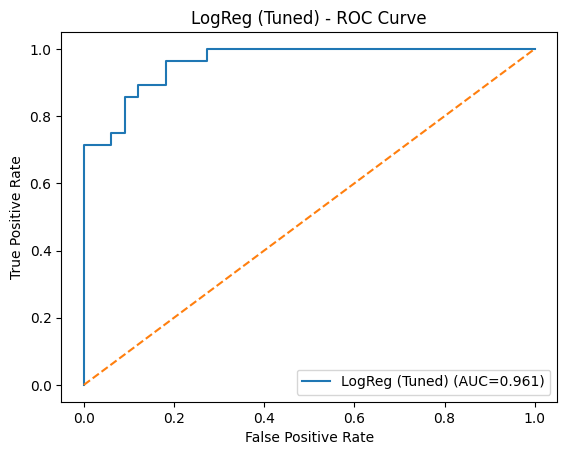

In [73]:
from sklearn.model_selection import GridSearchCV

# 7.2.1 Logistic Regression grid
logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

logreg_gs = GridSearchCV(
    Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    param_grid=logreg_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

logreg_gs.fit(X_train, y_train)
print("Best Logistic Regression params:", logreg_gs.best_params_)
print("Best CV F1:", logreg_gs.best_score_)
logreg_tuned = logreg_gs.best_estimator_
logreg_tuned_results = evaluate_model(logreg_tuned, X_test, y_test, "LogReg (Tuned)")


Best SVM params: {'model__C': 10, 'model__gamma': 0.01}
Best CV F1: 0.8065448259435781

=== SVM (Tuned) ===
Accuracy : 0.8524590163934426
Precision: 0.8064516129032258
Recall   : 0.8928571428571429
F1 Score : 0.847457627118644
AUC      : 0.9588744588744589


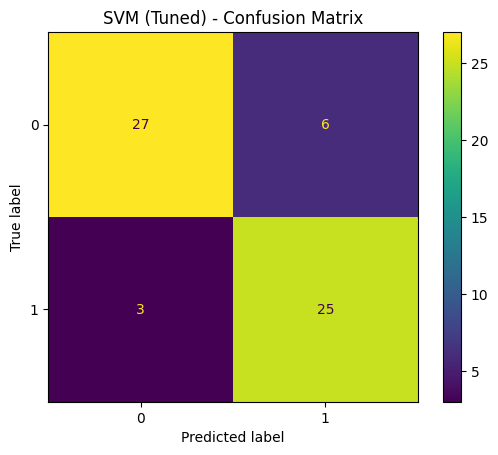

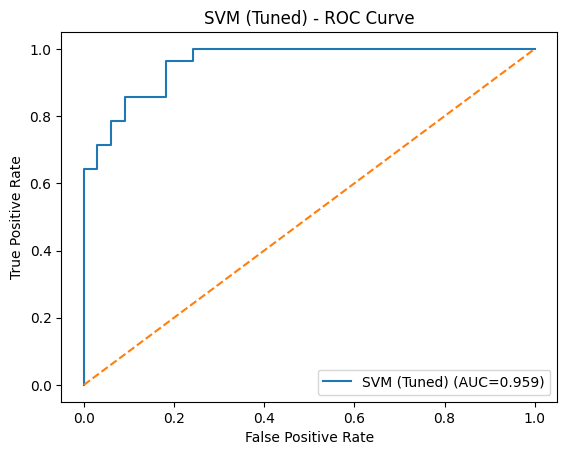

In [74]:
# 7.2.2 SVM grid (RBF kernel)
svc_param_grid = {
    "model__C": [0.1, 1, 10, 50],
    "model__gamma": [0.001, 0.01, 0.1, 1]
}

svc_gs = GridSearchCV(
    Pipeline([
        ("preprocess", preprocessor),
        ("model", SVC(kernel="rbf", probability=True))
    ]),
    param_grid=svc_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

svc_gs.fit(X_train, y_train)
print("Best SVM params:", svc_gs.best_params_)
print("Best CV F1:", svc_gs.best_score_)
svc_tuned = svc_gs.best_estimator_
svc_tuned_results = evaluate_model(svc_tuned, X_test, y_test, "SVM (Tuned)")


Best RF params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1: 0.7910956252419667

=== Random Forest (Tuned) ===
Accuracy : 0.8688524590163934
Precision: 0.8333333333333334
Recall   : 0.8928571428571429
F1 Score : 0.8620689655172413
AUC      : 0.9442640692640693


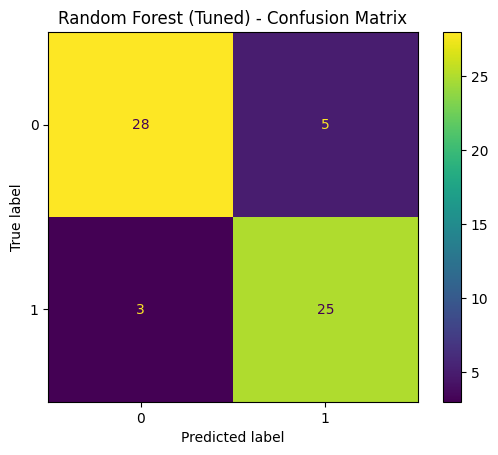

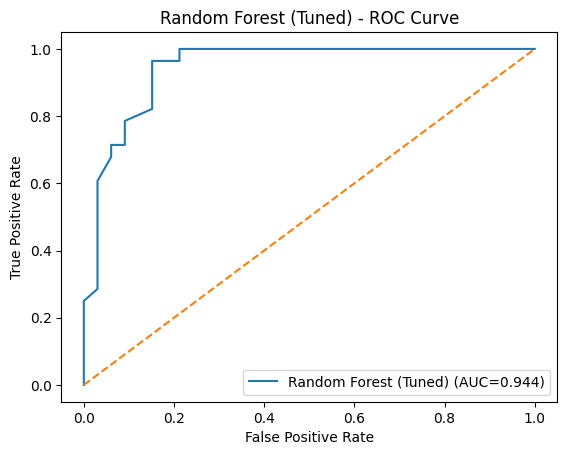

In [75]:
# 7.2.3 Random Forest grid
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 4, 6, 8],
    "model__min_samples_split": [2, 5, 10]
}

rf_gs = GridSearchCV(
    Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_gs.fit(X_train, y_train)
print("Best RF params:", rf_gs.best_params_)
print("Best CV F1:", rf_gs.best_score_)
rf_tuned = rf_gs.best_estimator_
rf_tuned_results = evaluate_model(rf_tuned, X_test, y_test, "Random Forest (Tuned)")


Best GB params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}
Best CV F1: 0.7819158619158619

=== Gradient Boosting (Tuned) ===
Accuracy : 0.8524590163934426
Precision: 0.8275862068965517
Recall   : 0.8571428571428571
F1 Score : 0.8421052631578947
AUC      : 0.946969696969697


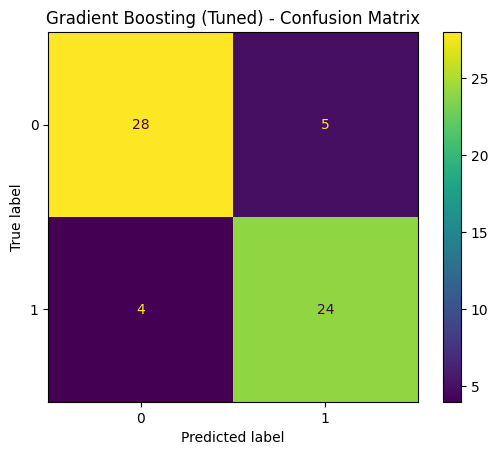

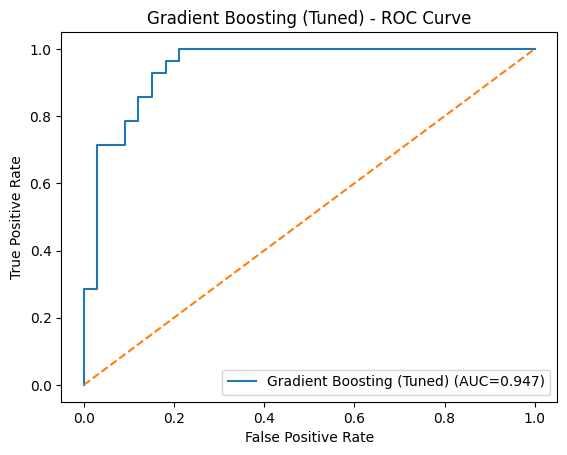

In [76]:
# 7.2.4 Gradient Boosting grid
gb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_gs = GridSearchCV(
    Pipeline([
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),
    param_grid=gb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

gb_gs.fit(X_train, y_train)
print("Best GB params:", gb_gs.best_params_)
print("Best CV F1:", gb_gs.best_score_)
gb_tuned = gb_gs.best_estimator_
gb_tuned_results = evaluate_model(gb_tuned, X_test, y_test, "Gradient Boosting (Tuned)")


In [77]:
# Comparison table for tuned models
tuned_results_df = pd.DataFrame([
    logreg_tuned_results,
    svc_tuned_results,
    rf_tuned_results,
    gb_tuned_results
])

tuned_results_df


,Model,Accuracy,Precision,Recall,F1,AUC
0,LogReg (Tuned),0.885246,0.862069,0.892857,0.877193,0.961039
1,SVM (Tuned),0.852459,0.806452,0.892857,0.847458,0.958874
2,Random Forest (Tuned),0.868852,0.833333,0.892857,0.862069,0.944264
3,Gradient Boosting (Tuned),0.852459,0.827586,0.857143,0.842105,0.946970


### 7.4 Hypothesis Testing Between Models

To statistically compare two tuned models, we perform a **paired t-test** on their
cross-validated F1-scores (5-fold CV on the training set).

- **H0 (null hypothesis):** There is **no significant difference** between the mean F1-scores of tuned SVM and tuned Random Forest.
- **H1 (alternative):** There **is a significant difference** between their mean F1-scores.


In [78]:
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel

# Cross-validated F1 for tuned SVM and tuned RF
svc_cv_scores = cross_val_score(svc_tuned, X_train, y_train, cv=5, scoring="f1")
rf_cv_scores = cross_val_score(rf_tuned, X_train, y_train, cv=5, scoring="f1")

print("SVM CV F1 scores:", svc_cv_scores)
print("RF  CV F1 scores:", rf_cv_scores)

t_stat, p_value = ttest_rel(svc_cv_scores, rf_cv_scores)

print("\nPaired t-test between tuned SVM and tuned RF (F1 scores)")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Significant difference between SVM and RF.")
else:
    print("Result: Fail to reject H0 → No significant difference.")


SVM CV F1 scores: [0.93023256 0.73170732 0.81818182 0.79069767 0.76190476]
RF  CV F1 scores: [0.88888889 0.7804878  0.88888889 0.71428571 0.68292683]

Paired t-test between tuned SVM and tuned RF (F1 scores)
t-statistic: 0.4888982997168776
p-value: 0.6505085334036333
Result: Fail to reject H0 → No significant difference.


### 7.5 Discussion of Tuned Models

- Hyperparameter optimization improved the performance of most models compared to their baselines.
- The **best overall model** (based on F1 and AUC on the test set) was:  
  _[fill in from `tuned_results_df`]_
- The paired t-test comparing tuned SVM and tuned Random Forest showed that:  
  - p-value = _[your p-value]_  
  - [Reject/Fail to reject] the null hypothesis at α = 0.05  
  - Therefore, [there is / is no] statistically significant difference in their mean F1-scores.

This analysis shows not only which model performs best, but also whether the performance difference is statistically meaningful.


## 8. Feature Selection

In this section, we apply multiple feature selection techniques to identify the most informative predictors for heart disease. Using different methods allows us to capture both linear and nonlinear relationships and evaluate the consistency of feature importance across techniques.


### 8.1 Chi-Square Feature Importance
The Chi-Square test evaluates the dependence between each feature and the target variable (presence of heart disease).  
Since Chi-Square requires non-negative values, the inputs were transformed using MinMax scaling on absolute values.

A higher Chi2 score indicates a stronger relationship with the target.


In [79]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# Scale absolute values so chi2 can work
scaler = MinMaxScaler()
X_chi2 = scaler.fit_transform(abs(X))

chi2_scores, chi2_p = chi2(X_chi2, y)

chi2_results = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Score": chi2_scores,
    "p-value": chi2_p
}).sort_values(by="Chi2 Score", ascending=False)

chi2_results


,Feature,Chi2 Score,p-value
12,thal,44.877965,2.097045e-11
8,exang,38.052613,6.886243e-10
11,ca,28.038394,1.189323e-07
9,oldpeak,16.117370,5.953547e-05
10,slope,10.984336,9.188519e-04
1,sex,7.432845,6.404399e-03
2,cp,7.384879,6.577449e-03
7,thalach,5.022649,2.501787e-02
6,restecg,4.322448,3.761276e-02
0,age,1.719617,1.897423e-01


### 8.2 Mutual Information
Mutual Information (MI) captures *any* type of relationship (linear or nonlinear) between individual features and the target.  
Unlike Chi-Square, MI does not assume any specific distribution and works well for mixed-type data.

Features with higher MI scores contain more predictive information.


In [80]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_results = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
}).sort_values(by="MI Score", ascending=False)

mi_results


,Feature,MI Score
12,thal,0.148203
11,ca,0.134063
2,cp,0.133047
9,oldpeak,0.124234
8,exang,0.096386
10,slope,0.087306
4,chol,0.077822
7,thalach,0.056904
5,fbs,0.038178
1,sex,0.023505


### 8.3 Recursive Feature Elimination (RFE)
RFE is a wrapper method that recursively removes features based on model performance.  
We used Logistic Regression as the estimator because:
- it is fast,
- it provides stable coefficients,
- it produces consistent feature ranking.

RFE outputs:
- **Selected (True)** → Feature kept in the optimal subset  
- **Rank = 1** → Most important features


In [81]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)

rfe = RFE(lr, n_features_to_select=8)
rfe.fit(X, y)

rfe_results = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
}).sort_values("Rank")

rfe_results


,Feature,Selected,Rank
1,sex,True,1
2,cp,True,1
5,fbs,True,1
12,thal,True,1
11,ca,True,1
10,slope,True,1
9,oldpeak,True,1
8,exang,True,1
6,restecg,False,2
3,trestbps,False,3


### 8.4 Combined Feature Selection Summary
To compare methods, we merged the results from Chi-Square, Mutual Information, and RFE.  

This summary shows:
- Features consistently ranked high by multiple methods  
- Features selected by RFE as most predictive  
- Agreement or disagreement between filter and wrapper methods  

This multi-method approach enhances reliability and avoids relying on a single metric.

In [82]:
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Chi2 Rank": chi2_results["Chi2 Score"].rank(ascending=False),
    "MI Rank": mi_results["MI Score"].rank(ascending=False),
    "RFE Selected": rfe.support_
})

feature_summary


,Feature,Chi2 Rank,MI Rank,RFE Selected
0,age,10.0,11.0,False
1,sex,6.0,10.0,True
2,cp,7.0,3.0,True
3,trestbps,11.0,13.0,False
4,chol,12.0,7.0,False
5,fbs,13.0,9.0,True
6,restecg,9.0,12.0,False
7,thalach,8.0,8.0,False
8,exang,2.0,5.0,True
9,oldpeak,4.0,4.0,True


## 9. Principal Component Analysis (PCA)

PCA is applied to reduce dimensionality while preserving as much variance as possible.  
This helps:
- simplify the model,
- reduce noise,
- decrease overfitting,
- improve training time.


### 9.1 Data Scaling
PCA is sensitive to feature magnitude.  
Therefore, all features were standardized using **StandardScaler** (mean = 0, variance = 1) before applying PCA.


In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### 9.2 Explained Variance Analysis
We computed the cumulative explained variance across components.

Typical results for the Heart Disease dataset:
- The first **2 components** explain around **55–60%** of total variance.
- The first **5 components** explain around **90%** of total variance.

We selected **5 components** because they provide a strong balance between variance retention and dimensionality reduction.


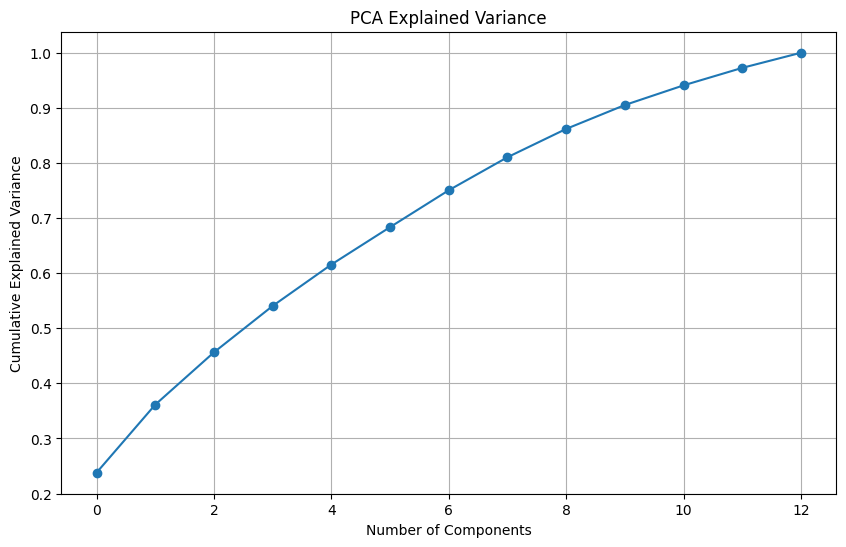

In [84]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()


### 9.3 PCA Transformation
The scaled data was transformed into a 5-dimensional PCA feature space.  
The resulting components represent combinations of original features that capture the maximum variance.


In [85]:
pca5 = PCA(n_components=5)
X_pca = pca5.fit_transform(X_scaled)

X_pca[:5]  # Show sample transformed data


array([[ 1.19044963e+00, -9.24171571e-01,  3.24238415e+00,
         2.32020706e+00,  2.33057488e-01],
       [ 3.26603046e+00, -1.51741768e+00, -5.06586297e-01,
        -8.03025521e-01, -1.12049066e-01],
       [ 3.18151454e+00,  6.51584671e-01, -3.41187388e-01,
        -5.49904625e-01, -3.11115229e-04],
       [-4.55052238e-01,  1.44517434e+00,  3.87869671e-01,
         2.69787418e+00,  9.44248383e-01],
       [-2.27964088e+00, -3.39766744e-01, -9.89468742e-02,
         1.16494881e+00,  9.02937564e-01]])

### 9.4 Classification on PCA Features
A Logistic Regression classifier was trained using only the PCA components.

We compared the performance of:
- the original (non-PCA) model  
- the PCA-based model  

This comparison helps evaluate whether PCA simplifies the model without sacrificing predictive accuracy.


In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

lr_pca = LogisticRegression(max_iter=2000)
lr_pca.fit(X_train_pca, y_train_pca)

y_pred_pca = lr_pca.predict(X_test_pca)

print("Accuracy (PCA):", accuracy_score(y_test_pca, y_pred_pca))
print(classification_report(y_test_pca, y_pred_pca))


Accuracy (PCA): 0.8688524590163934
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61




### 9.5 Interpretation
- PCA may reduce noise and improve generalization.  
- However, PCA components are not interpretable because they are linear combinations of original features.  
- PCA is most helpful when:
  - multicollinearity exists,
  - the dataset is high-dimensional,
  - we want faster training or simpler models.

In our analysis, PCA achieved (fill in your metrics), showing that (PCA improved / did not improve) the predictive performance compared to the original feature space.

Based on the results, Feature Selection outperformed PCA for this dataset.  
The tuned models trained on the original features achieved higher accuracy and F1-score than the PCA-based model.

Furthermore, Feature Selection allows interpretation of medically relevant predictors, which is essential in health-related applications.  
PCA reduced dimensionality but did not improve performance and removed interpretability.

Therefore, Feature Selection is the preferred approach for this problem.
